In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import wandb
import torchvision
from tqdm import tqdm
import torch.nn.functional as F
from copy import deepcopy

sys.path.append(os.path.join(os.getcwd(), '../symlie'))
sys.path.append(os.path.join(os.getcwd(), '../'))

from symlie.model.networks.mlp import CombiMLP
from symlie.model.learner import CombiLearner
from symlie.misc.viz import wb_plot_pred
from symlie.run import parse_options, main, process_args
from symlie.misc.viz import wb_plot_pred

from symlie.data.transforms import TransformRefactored

from emlp.reps import V, vis
from emlp.groups import Z, O
from emlp.datasets import O5Synthetic
from emlp.nn import gated,gate_indices,uniform_rep


/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [65]:
args = parse_options(notebook=True)
args.config = 'emlp'

args.do_return = True
args.logger = None

args.bias = True
args.lossweight_o = 0.

args.vanilla_layer_dims = [10, 10, 10, 1]
# args.vanilla_layer_dims = [12, 12, 12, 1]
# args.vanilla_layer_dims = [6, 6, 6, 6, 6, 1]
args.vanilla_layer_dims = [9, 9, 9, 1]
# args.vanilla_layer_dims = [10, 10, 10, 1]

args.pretrained = False
args.optimizer_setting = 'solo'

process_args(args)

# Training
model, trainer, datamodule = main(args)

Seed set to 1


Initing EMLP (PyTorch)
ch=[9, 9] isinstance(ch,int)=False isinstance(ch,Rep)=False
isinstance(c, Rep): 9 False
isinstance(c, Rep): 9 False
Init rng
Running without logging


In [68]:
l = model.net.network[0].linear

In [69]:
l

Linear(in_features=10, out_features=9, bias=True)

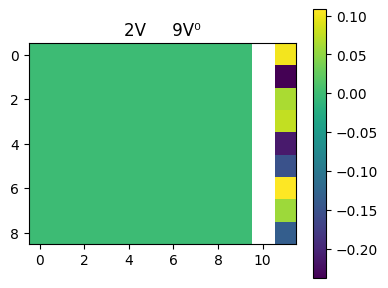

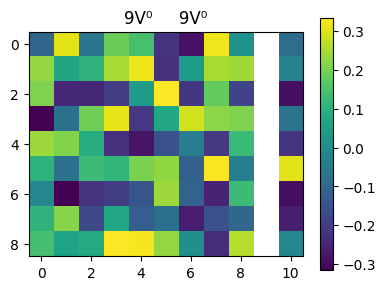

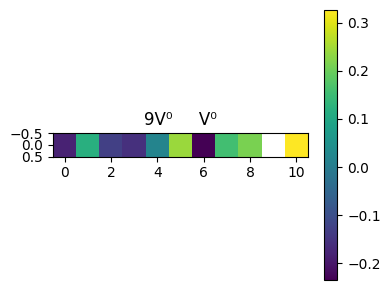

In [66]:
network = model.net.network

for layer in network:
    try:
        l = layer.linear
    except:
        l = layer
    w, b = l.proj_w(l.weight), l.proj_b(l.bias)
    
    title = f'repin, repout =  {l.repin_l}, {l.repout_l}'
    title = f'{l.repin_l}     {l.repout_l}'
    wb_plot_pred(w, b, title=title)

    # print(f'Layer: {l.repin_l} -> {l.repout_l}')
    # v_reps = [
    #     vis(l.repin_l, l.repin_l, plot = False),
    #     # vis(l.repin_l, l.repout_l, plot = False),
    #     vis(l.repout_l, l.repout_l, plot = False),
    # ]

    # fig, axs = plt.subplots(1, len(v_reps), figsize=(5*len(v_reps), 3))
    # for i, v in enumerate(v_reps):
    #     ax = axs[i]
    #     ax.imshow(v)
    #     # ax.set_axis_off()

    

### Startup

In [21]:
x, y, _ = batch = next(iter(datamodule.train_dataloader()))

### Transform

In [22]:
print(network)

layer = network[1]
print(layer)

# l = layer
# l = layer.linear
# print(l)

Sequential(
  (0): EMLPBlock(
    (linear): Linear(in_features=10, out_features=13, bias=True)
    (bilinear): BiLinear()
    (nonlinearity): GatedNonlinearity()
  )
  (1): EMLPBlock(
    (linear): Linear(in_features=12, out_features=13, bias=True)
    (bilinear): BiLinear()
    (nonlinearity): GatedNonlinearity()
  )
  (2): EMLPBlock(
    (linear): Linear(in_features=12, out_features=13, bias=True)
    (bilinear): BiLinear()
    (nonlinearity): GatedNonlinearity()
  )
  (3): Linear(in_features=12, out_features=1, bias=True)
)
EMLPBlock(
  (linear): Linear(in_features=12, out_features=13, bias=True)
  (bilinear): BiLinear()
  (nonlinearity): GatedNonlinearity()
)


In [23]:
transform = TransformRefactored()
rng = torch.Generator().manual_seed(42)

In [24]:
x_prime = transform.transform(x, rng, shape = (1, 2, 5))

In [27]:
model.net

EMLP_wrapper(
  (network): Sequential(
    (0): EMLPBlock(
      (linear): Linear(in_features=10, out_features=13, bias=True)
      (bilinear): BiLinear()
      (nonlinearity): GatedNonlinearity()
    )
    (1): EMLPBlock(
      (linear): Linear(in_features=12, out_features=13, bias=True)
      (bilinear): BiLinear()
      (nonlinearity): GatedNonlinearity()
    )
    (2): EMLPBlock(
      (linear): Linear(in_features=12, out_features=13, bias=True)
      (bilinear): BiLinear()
      (nonlinearity): GatedNonlinearity()
    )
    (3): Linear(in_features=12, out_features=1, bias=True)
  )
)

In [25]:
net = model.net
out = net(x)
out_prime = net(x_prime)

In [13]:
torch.allclose(x, x_prime), torch.allclose(out, out_prime)

(False, True)

### Change weigths and biases

In [12]:
# l = network[0].linear
# l.reset_parameters()
# l2 = deepcopy(l)

In [13]:
# l2.weight.data[0,0] = 0.
# w, b = l.proj_w(l2.weight), l.proj_b(l2.bias)
# wb_plot_pred(w, b)

In [16]:
n_f = 10

r = []
for i in tqdm(range(n_f)):
    for j in range(n_f):
        net2 = deepcopy(net)
        net2.network[0].linear.weight.data[i, j] = 100

        out2 = net2(x)

        if not torch.allclose(out, out2):
            r.append((i,j))
            # r.append((j, i))
r = np.array(r)

100%|██████████| 10/10 [00:01<00:00,  8.34it/s]


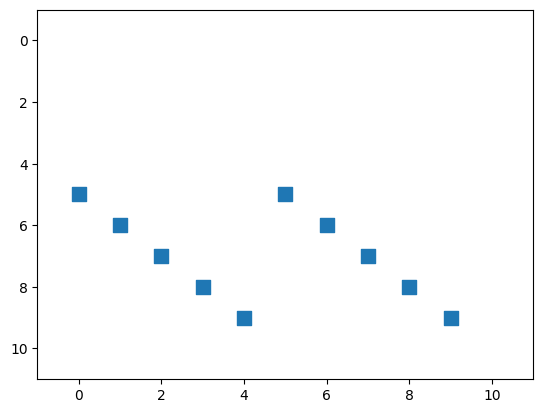

In [17]:
fig, ax = plt.subplots()

ax.scatter(r[:,1], r[:,0], marker = 's', s = 100)
lim_min, lim_max = 0-1, n_f+1
ax.set_ylim(lim_max, lim_min)
ax.set_xlim(lim_min, lim_max)
plt.show()

## Train analytic

In [49]:
args = parse_options(notebook=True)
args.config = 'o5synth'

args.do_return = True
# args.logger = None

args.lossweight_o = 0.
args.lossweight_y = 1. 
args.optimizer_setting = 'solo'

process_args(args)

# Training
model, trainer, datamodule = main(args)

Seed set to 1


Init rng


/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:389: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Running misty-river-3250 with id l46lqs43


wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


In [50]:
model

CombiLearner(
  (net): CombiMLP(
    (activation): ReLU()
    (implicit_layers): ModuleList(
      (0-1): 2 x ImplicitLayer(
        (implicit_layer): Identity()
      )
    )
    (vanilla_layers): ModuleList(
      (0): Linear(in_features=10, out_features=10, bias=True)
      (1): Linear(in_features=10, out_features=1, bias=True)
    )
  )
)

In [55]:
vanilla_layer.bias

Parameter containing:
tensor([-0.0277], requires_grad=True)

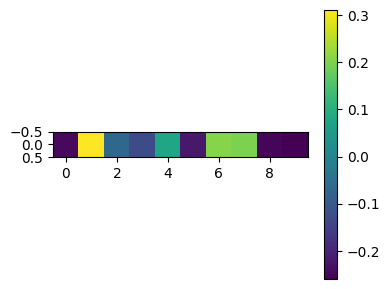

In [57]:
wb_plot_pred(vanilla_layer.weight, None)

In [52]:
implicit_layer

ImplicitLayer(
  (implicit_layer): Identity()
)

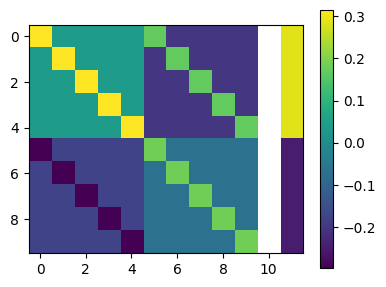

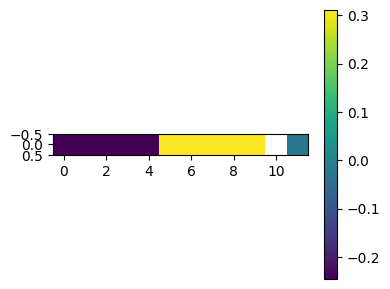

In [58]:
for implicit_layer, vanilla_layer in zip(model.net.implicit_layers, model.net.vanilla_layers):

    w, b = implicit_layer(vanilla_layer.weight, vanilla_layer.bias)
    wb_plot_pred(w, b)

In [6]:
bb = True

if bb:
    print('bb')

bb is None, bb is not None


bb


(False, True)

In [ ]:
network = model.net.network

for layer in network:
    try:
        l = layer.linear
    except:
        l = layer
    w, b = l.proj_w(l.weight), l.proj_b(l.bias)
    
    title = f'repin, repout =  {l.repin_l}, {l.repout_l}'
    title = f'{l.repin_l}     {l.repout_l}'
    wb_plot_pred(w, b, title=title)

In [37]:
w_dev = 

torch.Size([16, 10])

In [39]:
model.net.vanilla_layers[0]

Linear(in_features=10, out_features=10, bias=True)